Powers to test: [1.1, 1.3, 1.5, 1.7, 1.9]
Alphas to test: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]
--- Loading data ---
Data aligned. Found 9559 common samples.
Initial number of OTUs: 4460
[taxa-map] Mapped 4460/4460 OTUs (rename-only; no collapse).
Example renamed columns: ['Bacteroidaceae_Bacteroides__ef63210b', 'Bacteroidaceae_Bacteroides__fee9d92e', 'Ruminococcaceae_Faecalibacterium__26beb329', 'Bacteroidaceae_Bacteroides__48645283', 'Ruminococcaceae_Faecalibacterium__6bfe71f5']
Any duplicates after rename? False
Number of OTUs after filtering: 819
Using Y = log1p(raw counts) for Tweedie fitting.
Excluding 15 metadata cols from X (to reduce UKB missingness): ['cat', 'dog', 'multivitamin', 'other_supplement_frequency', 'cosmetics_frequency', 'fermented_plant_frequency', 'homecooked_meals_frequency', 'meat_eggs_frequency', 'sugary_sweets_frequency', 'vivid_dreams', 'sugar_sweetened_drink_frequency', 'artificial_sweeteners', 'olive_oil', 'prepared_meals_frequency', 'ready_t

Processing OTUs:   0%|          | 0/819 [00:00<?, ?it/s]


Saved full results to: ./hongrui_result/Tweedie_NestedCV_Results/nestedcv_tweedie_all_otus_results.csv

--- Top 10 OTUs by OUTER-CV mean R² (log1p scale; proper nested CV) ---
                                                        OTU  outer_r2_mean  outer_r2_std  outer_r2_raw_mean  outer_best_alpha_mode  outer_best_power_mode
               Bifidobacteriaceae_Bifidobacterium__a5d26678       0.088992      0.005407          -0.208102                   0.10                    1.1
Christensenellaceae_Christensenellaceae_R-7_group__51c02d84       0.072801      0.011700          -0.156775                   0.01                    1.1
          Ruminococcaceae_Ruminococcaceae_UCG-002__b4b6efb2       0.071678      0.014336          -0.238172                   0.10                    1.1
    Ruminococcaceae_Ruminococcaceae_NK4A214_group__760c2f19       0.067134      0.011207          -0.040294                   0.01                    1.1
          Ruminococcaceae_Ruminococcaceae_UCG-002__e8

/tmp/ipykernel_2157392/3302123843.py:464: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2157392/3302123843.py:491: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Saved: ./hongrui_result/Tweedie_NestedCV_Results/top10_nestedcv_tweedie_outer_r2_raw_barplot.pdf
Saved: ./hongrui_result/Tweedie_NestedCV_Results/best_otu_last_outerfold_scatter.pdf

Analysis complete.
[SAVED] ./hongrui_result/Tweedie_NestedCV_Results/top10_feature_importance/top10_otu_feature_importance.pdf
[SAVED] Per-OTU PNGs in: ./hongrui_result/Tweedie_NestedCV_Results/top10_feature_importance

--- Saving OTU Tweedie models with outer_r2_mean > 0.04 ---
OTUs eligible for saving: 35


Fitting final Tweedie models:   0%|          | 0/35 [00:00<?, ?it/s]

Saved 35 Tweedie OTU models to: Tweedie_OTU_Trained_Models/tweedie_otu_models.pkl
Saved training metadata to: Tweedie_OTU_Trained_Models/tweedie_training_metadata.json
Saved OTU save-list to: Tweedie_OTU_Trained_Models/saved_otus_r2_gt_threshold.csv

Deployment model saving complete.
Saved: ./hongrui_result/Tweedie_NestedCV_Results/otu_count_vs_r2_threshold.pdf

All done.


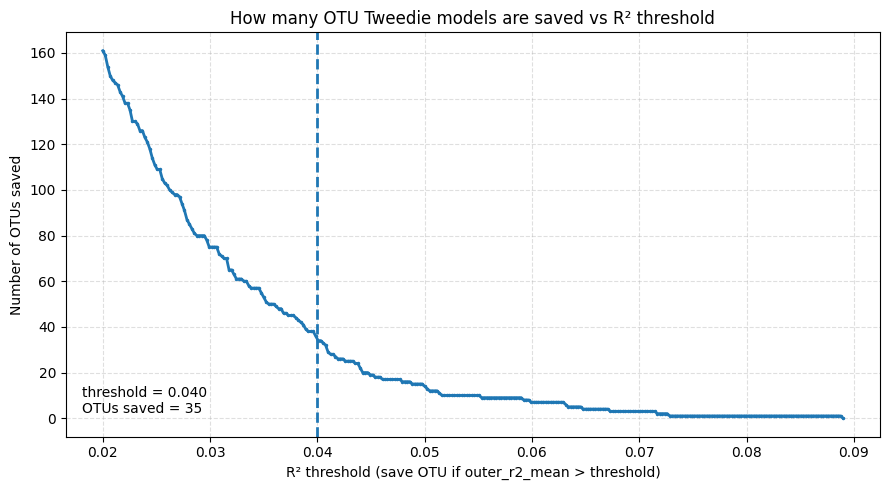

In [2]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# Nested-CV Tweedie Regression to Predict Microbiome Features (Y)
# from Lifestyle/Metadata Features (X), with NO leakage
#
# Mirrors the ridge pipeline:
# 1) TRUE nested CV: outer CV evaluates; inner CV tunes alpha + power
# 2) No pre-CV imputation: SimpleImputer inside Pipeline
# 3) Optionally prevents subject leakage: GroupKFold if you have a subject_id
# 4) Stores outer-fold R2 mean/std and hyperparameter distribution
# 5) Top-10 OTU plots
# 6) Best-OTU scatter plot
# 7) Feature-importance plots for top-10 OTUs
# 8) Saves final trained models for OTUs above threshold
#
# Important:
# - TweedieRegressor must be trained on NONNEGATIVE Y
# - Therefore, we fit on raw counts (or relative abundance), NOT on log1p(Y)
# - But for comparability with the ridge script, we define:
#       outer_r2_mean     = R² on log1p(Y_true) vs log1p(Y_pred)
#       outer_r2_raw_mean = R² on raw Y_true vs raw Y_pred
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm  # use tqdm if not in notebook
from pathlib import Path
from joblib import Parallel, delayed
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.model_selection import KFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import r2_score


# ============================================================
# 1. Configuration
# ============================================================
otu_file_path = "./Data/Cleaned_data/AGP_Otu_Data.csv"
metadata_file_path = "./Data/Cleaned_data/processed_metadata.csv"

metadata_index_col = "sample_name"
otu_index_col = 0

output_dir = "./hongrui_result/Tweedie_NestedCV_Results/"
os.makedirs(output_dir, exist_ok=True)

n_cpu = -1

# Hard-coded exclusion list (same as ridge script)
EXCLUDE_METADATA_COLS = [
    "cat",
    "dog",
    "multivitamin",
    "other_supplement_frequency",
    "cosmetics_frequency",
    "fermented_plant_frequency",
    "homecooked_meals_frequency",
    "meat_eggs_frequency",
    "sugary_sweets_frequency",
    "vivid_dreams",
    "sugar_sweetened_drink_frequency",
    "artificial_sweeteners",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
]

# CV config
n_splits_outer = 5
n_splits_inner = 5
random_state_cv = 42

# OTU filter config (based on mean relative abundance)
abundance_threshold = 0.0001

# Tweedie hyper-parameter grid
# power must be in (1, 2) for compound Poisson-Gamma (zero mass + positive continuous)
powers_to_test = [1.1, 1.3, 1.5, 1.7, 1.9]
alphas_to_test = np.logspace(-3, 3, 7)  # 0.001 ... 1000
print(f"Powers to test: {powers_to_test}")
print(f"Alphas to test: {alphas_to_test}")

subject_id_col = None  # make sure each participant only has one sample, otherwise change this

# Target choice
# Tweedie must use NONNEGATIVE target
use_raw_counts = True   # True => raw counts, False => relative abundance
# NOTE: outer_r2_mean will still be evaluated on log1p scale for comparability

# Final model saving threshold (same role as ridge script)
r2_save_threshold = 0.04

# Feature importance settings
TOP_FEATS = 25


# ============================================================
# 2. Load and Prepare Data
# ============================================================
print("--- Loading data ---")
metadata_df = pd.read_csv(metadata_file_path, index_col=metadata_index_col)
otu_df = pd.read_csv(otu_file_path, index_col=otu_index_col)

# Align samples
common_samples = metadata_df.index.intersection(otu_df.index)
metadata_df = metadata_df.loc[common_samples].copy()
otu_df = otu_df.loc[common_samples].copy()
print(f"Data aligned. Found {len(common_samples)} common samples.")
print(f"Initial number of OTUs: {otu_df.shape[1]}")

# ------------------------------------------------------------
# 2.5 Taxa-map rename ONLY (NO collapse; preserves results)
# md5 OTU -> Family_Genus__<md5prefix> (unique), else Unmapped__<md5prefix>
# ------------------------------------------------------------
taxa_map_path = Path("./Data/Raw_Data/taxa_md5.xls")  # TSV despite .xls

taxa_df = pd.read_csv(
    taxa_map_path,
    sep="\t",
    header=0,
    index_col=0,
    engine="python"
)

# Clean index + build Family_Genus
taxa_df.index = taxa_df.index.astype(str).str.strip()
taxa_df["Family"] = taxa_df["Family"].fillna("UnclassifiedFamily").astype(str).str.strip()
taxa_df["Genus"]  = taxa_df["Genus"].fillna("UnclassifiedGenus").astype(str).str.strip()
taxa_df["Family_Genus"] = taxa_df["Family"] + "_" + taxa_df["Genus"]

mapper = taxa_df["Family_Genus"].to_dict()

md5_prefix_len = 8

def make_unique(names):
    counts = {}
    out = []
    for n in names:
        k = counts.get(n, 0) + 1
        counts[n] = k
        out.append(n if k == 1 else f"{n}__{k}")
    return out

otu_md5 = otu_df.columns.astype(str).str.strip()

new_cols = [
    f"{mapper.get(m, 'Unmapped')}__{m[:md5_prefix_len]}"
    for m in otu_md5
]

otu_df = otu_df.copy()
otu_df.columns = make_unique(new_cols)

n_mapped = sum(mapper.get(m, None) is not None for m in otu_md5)
print(f"[taxa-map] Mapped {n_mapped}/{len(otu_md5)} OTUs (rename-only; no collapse).")
print("Example renamed columns:", list(otu_df.columns[:5]))
print("Any duplicates after rename?", pd.Index(otu_df.columns).duplicated().any())

# Filter OTUs by mean relative abundance
otu_rel_abund = otu_df.div(otu_df.sum(axis=1), axis=0)
mean_rel_abund = otu_rel_abund.mean(axis=0)
otus_to_keep = mean_rel_abund[mean_rel_abund > abundance_threshold].index
otu_df_filtered = otu_df[otus_to_keep].copy()
print(f"Number of OTUs after filtering: {otu_df_filtered.shape[1]}")

# Define Y matrix for Tweedie (must be nonnegative)
Y = np.log1p(otu_df_filtered.astype(float))
print("Using Y = log1p(raw counts) for Tweedie fitting.")

# Define X matrix (numeric only)
numeric_cols_all = metadata_df.select_dtypes(include=np.number).columns.tolist()

excluded_present = [c for c in EXCLUDE_METADATA_COLS if c in numeric_cols_all]
numeric_cols = [c for c in numeric_cols_all if c not in set(EXCLUDE_METADATA_COLS)]

if excluded_present:
    print(
        f"Excluding {len(excluded_present)} metadata cols from X (to reduce UKB missingness): "
        f"{excluded_present}"
    )

X = metadata_df[numeric_cols].copy()
print(f"Using {X.shape[1]} numeric metadata features as predictors.")

# Groups (optional)
groups = None
if subject_id_col is not None:
    if subject_id_col not in metadata_df.columns:
        raise ValueError(
            f"subject_id_col='{subject_id_col}' not found in metadata_df columns. "
            f"Available cols include: {list(metadata_df.columns)[:20]} ..."
        )
    groups = metadata_df[subject_id_col].values
    print(f"Using GroupKFold with groups from column: {subject_id_col}")


# ============================================================
# 3. Helpers
# ============================================================
def make_pipeline(alpha: float, power: float) -> Pipeline:
    """
    Pipeline that avoids leakage: impute + scale + Tweedie.
    link='log' ensures positive mean predictions.
    """
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("tweedie", TweedieRegressor(
            power=power,
            alpha=alpha,
            link="log",
            max_iter=1000
        ))
    ])

def get_cv_splitter(n_splits: int, use_groups: bool):
    """Return KFold or GroupKFold splitter."""
    if use_groups:
        return GroupKFold(n_splits=n_splits)
    return KFold(n_splits=n_splits, shuffle=True, random_state=random_state_cv)

def safe_r2(y_true, y_pred):
    """Avoid crashing when validation fold target is constant."""
    if np.nanvar(np.asarray(y_true, dtype=float)) < 1e-12:
        return np.nan
    return r2_score(y_true, y_pred)

def process_single_otu(
    otu_name,
    X,
    Y,
    alphas_to_test,
    powers_to_test,
    n_splits_outer,
    n_splits_inner,
    groups=None
):
    y = Y[otu_name].astype(float)

    # Primary comparison metric will be on log1p scale
    if np.nanvar(np.log1p(y.values)) < 1e-9:
        return {
            "OTU": otu_name,
            "outer_r2_mean": np.nan,          # log1p-scale R² (primary metric)
            "outer_r2_std": np.nan,
            "outer_r2_median": np.nan,
            "outer_r2_raw_mean": np.nan,      # raw-scale R²
            "outer_r2_raw_std": np.nan,
            "outer_r2_raw_median": np.nan,
            "outer_best_alpha_mode": np.nan,
            "outer_best_alpha_mean": np.nan,
            "outer_best_power_mode": np.nan,
            "outer_best_power_mean": np.nan,
            "n_samples": len(y),
            "last_fold_data": None
        }

    use_groups = groups is not None
    outer_splitter = get_cv_splitter(n_splits_outer, use_groups)
    inner_splitter = get_cv_splitter(n_splits_inner, use_groups)

    outer_r2_scores = []
    outer_r2_raw_scores = []
    outer_best_alphas = []
    outer_best_powers = []

    last_fold_data = {}

    outer_splits = (
        list(outer_splitter.split(X, y, groups=groups))
        if use_groups
        else list(outer_splitter.split(X, y))
    )

    for ofold, (tr_idx, te_idx) in enumerate(outer_splits):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # Inner CV to find best alpha + best power
        best_alpha = None
        best_power = None
        best_inner_score = -np.inf

        inner_splits = (
            list(inner_splitter.split(X_tr, y_tr, groups=groups[tr_idx]))
            if use_groups
            else list(inner_splitter.split(X_tr, y_tr))
        )

        for power in powers_to_test:
            for alpha in alphas_to_test:
                inner_scores = []

                for itr_idx, iva_idx in inner_splits:
                    X_itr, X_iva = X_tr.iloc[itr_idx], X_tr.iloc[iva_idx]
                    y_itr, y_iva = y_tr.iloc[itr_idx], y_tr.iloc[iva_idx]

                    try:
                        pipe = make_pipeline(alpha=alpha, power=power)
                        pipe.fit(X_itr, y_itr)

                        pred_iva = pipe.predict(X_iva)
                        pred_iva = np.clip(pred_iva, 0.0, None)

                        # Primary tuning metric: log1p-scale R²
                        score = safe_r2(y_iva, pred_iva)
                        if np.isfinite(score):
                            inner_scores.append(score)

                    except Exception:
                        continue

                if len(inner_scores) == 0:
                    inner_mean = -np.inf
                else:
                    inner_mean = np.mean(inner_scores)

                if inner_mean > best_inner_score:
                    best_inner_score = inner_mean
                    best_alpha = alpha
                    best_power = power

        # Fallback if all candidates fail
        if best_alpha is None:
            best_alpha = float(np.median(alphas_to_test))
        if best_power is None:
            best_power = float(powers_to_test[len(powers_to_test) // 2])

        # Final fit for this outer fold
        pipe = make_pipeline(best_alpha, best_power)
        pipe.fit(X_tr, y_tr)
        pred_te = pipe.predict(X_te)
        pred_te = np.clip(pred_te, 0.0, None)

        r2_log = safe_r2(y_te, pred_te)  # now this is R² on log1p scale
        r2_raw = safe_r2(np.expm1(y_te), np.expm1(pred_te))  # approximate raw-scale R²

        outer_r2_scores.append(r2_log)
        outer_r2_raw_scores.append(r2_raw)
        outer_best_alphas.append(best_alpha)
        outer_best_powers.append(best_power)

        # Save last fold for scatter plot
        if ofold == len(outer_splits) - 1:
            last_fold_data = {
                "y_true": y_te.values,
                "y_pred": pred_te,
                "alpha": best_alpha,
                "power": best_power
            }

    # Summaries
    outer_r2_scores = np.array(outer_r2_scores, dtype=float)
    outer_r2_raw_scores = np.array(outer_r2_raw_scores, dtype=float)

    r2_mean = np.nanmean(outer_r2_scores)
    r2_std = np.nanstd(outer_r2_scores, ddof=1)
    r2_median = np.nanmedian(outer_r2_scores)

    r2_raw_mean = np.nanmean(outer_r2_raw_scores)
    r2_raw_std = np.nanstd(outer_r2_raw_scores, ddof=1)
    r2_raw_median = np.nanmedian(outer_r2_raw_scores)

    unique_alphas, counts_alpha = np.unique(outer_best_alphas, return_counts=True)
    alpha_mode = unique_alphas[np.argmax(counts_alpha)]
    alpha_mean = np.mean(outer_best_alphas)

    unique_powers, counts_power = np.unique(outer_best_powers, return_counts=True)
    power_mode = unique_powers[np.argmax(counts_power)]
    power_mean = np.mean(outer_best_powers)

    return {
        "OTU": otu_name,
        "outer_r2_mean": float(r2_mean),
        "outer_r2_std": float(r2_std),
        "outer_r2_median": float(r2_median),
        "outer_r2_raw_mean": float(r2_raw_mean),
        "outer_r2_raw_std": float(r2_raw_std),
        "outer_r2_raw_median": float(r2_raw_median),
        "outer_best_alpha_mode": float(alpha_mode),
        "outer_best_alpha_mean": float(alpha_mean),
        "outer_best_power_mode": float(power_mode),
        "outer_best_power_mean": float(power_mean),
        "n_samples": len(y),
        "last_fold_data": last_fold_data
    }


# ============================================================
# 4. Nested CV per OTU
# ============================================================
print(f"\n--- Running Nested CV Tweedie (outer={n_splits_outer}, inner={n_splits_inner}) ---")
use_groups = groups is not None

print(f"Starting parallel processing with {n_cpu} CPUs...")

results_list = Parallel(n_jobs=n_cpu)(
    delayed(process_single_otu)(
        otu, X, Y, alphas_to_test, powers_to_test, n_splits_outer, n_splits_inner, groups
    ) for otu in tqdm(Y.columns, desc="Processing OTUs")
)

results_df = pd.DataFrame(results_list)

# Best OTU info based on primary metric (log1p-scale R²)
best_idx = results_df["outer_r2_mean"].idxmax()
best_otu_info = results_list[best_idx]

best_scatter = {
    "otu": best_otu_info["OTU"],
    "y_true": pd.Series(best_otu_info["last_fold_data"]["y_true"]),
    "y_pred": best_otu_info["last_fold_data"]["y_pred"],
    "r2_log": r2_score(
        np.log1p(best_otu_info["last_fold_data"]["y_true"]),
        np.log1p(best_otu_info["last_fold_data"]["y_pred"])
    ),
    "r2_raw": r2_score(
        best_otu_info["last_fold_data"]["y_true"],
        best_otu_info["last_fold_data"]["y_pred"]
    ),
    "alpha": best_otu_info["last_fold_data"]["alpha"],
    "power": best_otu_info["last_fold_data"]["power"],
    "outer_mean_r2": best_otu_info["outer_r2_mean"],
    "outer_mean_r2_raw": best_otu_info["outer_r2_raw_mean"]
}

# Save results
results_csv_path = os.path.join(output_dir, "nestedcv_tweedie_all_otus_results.csv")
results_df.to_csv(results_csv_path, index=False)
print(f"\nSaved full results to: {results_csv_path}")

# Rank and show Top 10
print("\n--- Top 10 OTUs by OUTER-CV mean R² (log1p scale; proper nested CV) ---")
ranked = results_df.dropna(subset=["outer_r2_mean"]).sort_values("outer_r2_mean", ascending=False)
print(
    ranked[
        ["OTU", "outer_r2_mean", "outer_r2_std", "outer_r2_raw_mean", "outer_best_alpha_mode", "outer_best_power_mode"]
    ].head(10).to_string(index=False)
)

top10_df = ranked.head(10).copy()


# ============================================================
# 5. Plots
# ============================================================
print("\n--- Generating Plots ---")

# Plot 1: Top 10 bar plot with error bars (std across OUTER folds)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x="outer_r2_mean",
    y="OTU",
    data=top10_df,
    orient="h",
    palette="viridis",
)
ax.errorbar(
    x=top10_df["outer_r2_mean"].values,
    y=np.arange(len(top10_df)),
    xerr=top10_df["outer_r2_std"].values,
    fmt="none",
    capsize=5
)
plt.title("Top 10 OTUs Predictable from Metadata (Nested CV Tweedie, log1p-scale R²)")
plt.xlabel("Outer-CV Mean R² (± SD across outer folds)")
plt.ylabel("OTU")
xmin = float(min(0.0, top10_df["outer_r2_mean"].min() - top10_df["outer_r2_std"].max()))
plt.xlim(left=xmin)
plt.tight_layout()
barplot_path = os.path.join(output_dir, "top10_nestedcv_tweedie_outer_r2_barplot.pdf")
plt.savefig(barplot_path)
plt.close()
print(f"Saved: {barplot_path}")

# Plot 1b: raw-scale R²
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x="outer_r2_raw_mean",
    y="OTU",
    data=top10_df,
    orient="h",
    palette="magma",
)
ax.errorbar(
    x=top10_df["outer_r2_raw_mean"].values,
    y=np.arange(len(top10_df)),
    xerr=top10_df["outer_r2_raw_std"].values,
    fmt="none",
    capsize=5
)
plt.title("Top 10 OTUs Predictable from Metadata (Nested CV Tweedie, raw-scale R²)")
plt.xlabel("Outer-CV Mean raw-scale R² (± SD across outer folds)")
plt.ylabel("OTU")
xmin = float(min(0.0, top10_df["outer_r2_raw_mean"].min() - top10_df["outer_r2_raw_std"].max()))
plt.xlim(left=xmin)
plt.tight_layout()
barplot_raw_path = os.path.join(output_dir, "top10_nestedcv_tweedie_outer_r2_raw_barplot.pdf")
plt.savefig(barplot_raw_path)
plt.close()
print(f"Saved: {barplot_raw_path}")

# Plot 2: Scatter for best OTU (last outer fold), on log1p scale
if best_scatter["otu"] is not None:
    otu_name = best_scatter["otu"]
    y_true = best_scatter["y_true"].astype(float)
    y_pred = np.array(best_scatter["y_pred"], dtype=float)
    r2_last_log = float(best_scatter["r2_log"])
    r2_last_raw = float(best_scatter["r2_raw"])
    alpha_last = float(best_scatter["alpha"])
    power_last = float(best_scatter["power"])
    outer_mean = float(best_scatter["outer_mean_r2"])
    outer_mean_raw = float(best_scatter["outer_mean_r2_raw"])

    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.5, label="Outer-fold predictions")

    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi], "--", linewidth=2, label="Identity (y = x)")

    plt.title(f"Best OTU: {otu_name}\nLast Outer Fold (alpha={alpha_last:g}, power={power_last:g})")
    plt.xlabel("True log1p(Y)")
    plt.ylabel("Predicted log1p(Y)")
    plt.text(
        0.05, 0.95,
        f"Last-fold R² (log1p) = {r2_last_log:.3f}\n"
        f"Last-fold R² (raw) = {r2_last_raw:.3f}\n"
        f"Outer mean R² (log1p) = {outer_mean:.3f}\n"
        f"Outer mean R² (raw) = {outer_mean_raw:.3f}",
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="wheat", alpha=0.5)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    scatter_path = os.path.join(output_dir, "best_otu_last_outerfold_scatter.pdf")
    plt.savefig(scatter_path)
    plt.close()
    print(f"Saved: {scatter_path}")
else:
    print("No OTU available for scatter plot.")

print("\nAnalysis complete.")


# ============================================================
# 6b) FEATURE IMPORTANCE for Top-10 OTU models (by outer_r2_mean)
#     Importance = standardized Tweedie coefficients
#     Output: 1 multi-page PDF + per-OTU PNGs
# ============================================================
fi_dir = os.path.join(output_dir, "top10_feature_importance")
os.makedirs(fi_dir, exist_ok=True)

pdf_path = os.path.join(fi_dir, "top10_otu_feature_importance.pdf")

need_cols = {"OTU", "outer_r2_mean", "outer_best_alpha_mode", "outer_best_power_mode"}
missing = need_cols - set(top10_df.columns)
if missing:
    raise ValueError(f"top10_df missing required columns: {missing}. Available: {list(top10_df.columns)}")

with PdfPages(pdf_path) as pdf:
    for i, row in enumerate(top10_df.itertuples(index=False), start=1):
        otu = row.OTU
        r2m = float(row.outer_r2_mean)

        alpha = row.outer_best_alpha_mode
        if pd.isna(alpha):
            alpha = float(np.median(alphas_to_test))
        else:
            alpha = float(alpha)

        power = row.outer_best_power_mode
        if pd.isna(power):
            power = float(powers_to_test[len(powers_to_test) // 2])
        else:
            power = float(power)

        # Fit final model on ALL data for this OTU
        y_all = Y[otu].astype(float).values
        pipe = make_pipeline(alpha, power).fit(X, y_all)

        coef = pd.Series(pipe.named_steps["tweedie"].coef_, index=X.columns)

        # Top |coef|
        imp = coef.abs().sort_values(ascending=False).head(TOP_FEATS)
        coef_top = coef.reindex(imp.index)

        plt.figure(figsize=(10, max(5, 0.35 * len(coef_top) + 2)))
        y_pos = np.arange(len(coef_top))[::-1]
        plt.barh(y_pos, coef_top.values[::-1])
        plt.yticks(y_pos, coef_top.index[::-1])
        plt.axvline(0.0, color="gray", linewidth=1.5)
        plt.xlabel("Standardized Tweedie coefficient")
        plt.title(
            f"#{i} OTU: {otu}\n"
            f"Outer-CV mean R²={r2m:.3f} | alpha={alpha:g} | power={power:g} | Top {TOP_FEATS} features"
        )
        plt.tight_layout()

        png_path = os.path.join(fi_dir, f"top10_{i:02d}_{otu}_feature_importance.png")
        plt.savefig(png_path, dpi=300)
        pdf.savefig()
        plt.close()

print(f"[SAVED] {pdf_path}")
print(f"[SAVED] Per-OTU PNGs in: {fi_dir}")


# ============================================================
# 7. SAVE "DEPLOYMENT" TWEEDIE MODELS for OTUs with R2 > threshold
#    - Uses alpha/power chosen from nested-CV summary
#    - Fits pipeline on ALL AGP samples (X, y) for each selected OTU
#    - Saves:
#        tweedie_otu_models.pkl
#        tweedie_training_metadata.json
# ============================================================
model_dir = Path("./Tweedie_OTU_Trained_Models/")
model_dir.mkdir(parents=True, exist_ok=True)

# Select OTUs to save
save_df = results_df.dropna(subset=["outer_r2_mean"]).copy()
save_df = save_df[save_df["outer_r2_mean"] > r2_save_threshold].copy()
save_df = save_df.sort_values("outer_r2_mean", ascending=False)

print(f"\n--- Saving OTU Tweedie models with outer_r2_mean > {r2_save_threshold} ---")
print(f"OTUs eligible for saving: {save_df.shape[0]}")

# Fit final models on ALL data for those OTUs
tweedie_models = {}
tweedie_model_info = {}

for row in tqdm(save_df.itertuples(index=False), total=save_df.shape[0], desc="Fitting final Tweedie models"):
    otu = row.OTU

    alpha = row.outer_best_alpha_mode
    if pd.isna(alpha):
        alpha = float(np.median(alphas_to_test))
    else:
        alpha = float(alpha)

    power = row.outer_best_power_mode
    if pd.isna(power):
        power = float(powers_to_test[len(powers_to_test) // 2])
    else:
        power = float(power)

    y_all = Y[otu].astype(float).values
    pipe = make_pipeline(alpha, power)
    pipe.fit(X, y_all)

    tweedie_models[otu] = pipe
    tweedie_model_info[otu] = {
        "alpha": alpha,
        "power": power,
        "outer_r2_mean": float(row.outer_r2_mean),
        "outer_r2_std": float(row.outer_r2_std),
        "outer_r2_median": float(row.outer_r2_median),
        "outer_r2_raw_mean": float(row.outer_r2_raw_mean),
        "outer_r2_raw_std": float(row.outer_r2_raw_std),
        "outer_r2_raw_median": float(row.outer_r2_raw_median),
        "outer_best_alpha_mode": float(row.outer_best_alpha_mode) if not pd.isna(row.outer_best_alpha_mode) else None,
        "outer_best_alpha_mean": float(row.outer_best_alpha_mean) if not pd.isna(row.outer_best_alpha_mean) else None,
        "outer_best_power_mode": float(row.outer_best_power_mode) if not pd.isna(row.outer_best_power_mode) else None,
        "outer_best_power_mean": float(row.outer_best_power_mean) if not pd.isna(row.outer_best_power_mean) else None,
    }

# Save models
models_path = model_dir / "tweedie_otu_models.pkl"
joblib.dump(tweedie_models, models_path)
print(f"Saved {len(tweedie_models)} Tweedie OTU models to: {models_path}")

# Save training metadata
train_meta = {
    "r2_save_threshold": r2_save_threshold,
    "abundance_threshold": float(abundance_threshold),
    "use_raw_counts": bool(use_raw_counts),
    "alphas_to_test": [float(a) for a in alphas_to_test],
    "powers_to_test": [float(p) for p in powers_to_test],
    "train_cols": list(X.columns),
    "saved_otus": list(save_df["OTU"].values),
    "tweedie_model_info": tweedie_model_info,
    "n_train_samples": int(X.shape[0]),
    "excluded_metadata_cols": list(EXCLUDE_METADATA_COLS),
    "primary_metric": "outer_r2_mean = R2(log1p(true_Y), log1p(predicted_Y))",
    "secondary_metric": "outer_r2_raw_mean = R2(true_Y, predicted_Y)",
}

try:
    train_meta["otus_kept_after_filter"] = list(otu_df_filtered.columns)
except Exception:
    pass

meta_path = model_dir / "tweedie_training_metadata.json"
with open(meta_path, "w") as f:
    json.dump(train_meta, f, indent=2)
print(f"Saved training metadata to: {meta_path}")

save_df_path = model_dir / "saved_otus_r2_gt_threshold.csv"
save_df.to_csv(save_df_path, index=False)
print(f"Saved OTU save-list to: {save_df_path}")

print("\nDeployment model saving complete.")


# ============================================================
# 8. Plot: number of OTUs saved vs R² threshold
#   x = R² threshold
#   y = count of OTUs with outer_r2_mean > threshold
# ============================================================
r2_vals = results_df["outer_r2_mean"].dropna().astype(float).values
r2_vals = r2_vals[np.isfinite(r2_vals)]

if r2_vals.size == 0:
    print("No valid outer_r2_mean values found; skipping threshold curve plot.")
else:
    r2_sorted = np.sort(r2_vals)
    n = r2_sorted.size

    x_min = float(max(0.02, r2_sorted.min()))
    x_max = float(r2_sorted.max())
    thresholds = np.linspace(x_min, x_max, 300)

    idx = np.searchsorted(r2_sorted, thresholds, side="right")
    n_saved = n - idx

    plt.figure(figsize=(9, 5))
    plt.plot(thresholds, n_saved, marker=".", markersize=3, linewidth=2)
    plt.title("How many OTU Tweedie models are saved vs R² threshold")
    plt.xlabel("R² threshold (save OTU if outer_r2_mean > threshold)")
    plt.ylabel("Number of OTUs saved")
    plt.grid(True, linestyle="--", alpha=0.4)

    t = float(r2_save_threshold)
    saved_at_t = int((r2_vals > t).sum())
    plt.axvline(t, linestyle="--", linewidth=2)
    plt.text(
        0.02, 0.05,
        f"threshold = {t:.3f}\nOTUs saved = {saved_at_t}",
        transform=plt.gca().transAxes,
        va="bottom"
    )

    plt.tight_layout()
    curve_path = os.path.join(output_dir, "otu_count_vs_r2_threshold.pdf")
    plt.savefig(curve_path)
    print(f"Saved: {curve_path}")

print("\nAll done.")